In [17]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
Num_EV = 5

In [9]:
def compare_scinario(DF,name,scinario1,scinario2,col):
    data1 = DF.loc[(DF["name"]==name)&(DF["Scinario"]==scinario1),col]
    data2 = DF.loc[(DF["name"]==name)&(DF["Scinario"]==scinario2),col]
    return data1 - data2
        

In [10]:

list_keys = ["SolarCapacity","BuyPowerEnergy"]
Dict = {}
    
for key in list_keys:
    Dict[key]={}
    for Num_EV in [3,5,10,15]:
        Dict[key][Num_EV]={}


for Num_EV in [3,5,10,15]:
    DF = pd.read_csv(f"TEEA_EV{Num_EV}.csv",index_col=0)
    for name in DF["name"].unique():
        print(name)
        DF = DF[DF["Scinario"]<7]
        Dict["SolarCapacity"][Num_EV][name]=compare_scinario(DF,name,5,6,"SolarCapacity").values[0]
        Dict["BuyPowerEnergy"][Num_EV][name]=compare_scinario(DF,name,5,6,"BuyPowerEnergy").values[0]

B11000005
B11000008
B11000010
B11000012
B11000021
B11000022
B11000031
B11000032
B11000033
B11000034
B11000040
B11000041
B11000044
B11000050
B11000052
B11000053
B11000059
B11000060
B11000065
B11000069
B11000072
B11000073
B11000074
B11000085
B11000091
B11000093
B11000094
B11000095
B11000096
B11000097
B11000100
B11000102
B11000103
B11000105
B11000108
B11000112
B11000116
B11000117
B11000121
B11000124
B11000125
B11000127
B11000137
B11000138
B11000140
B11000144
B11000148
B11000162
B11000164
B11000167
B11000173
B11000174
B11000182
B11000185
B11000193
B11000199
B11000202
B11000216
B11000219
B11000221
B11000223
B11000227
B11000228
B11000230
B11000233
B11000237
B11000242
B11000245
B11000246
B11000249
B11000251
B11000252
B11000253
B11000254
B11000255
B11000256
B11000260
B11000264
B11000265
B11000268
B11000269
B11000271
B11000272
B11000273
B11000274
B11000275
B11000276
B11000278
B11000280
B11000281
B11000284
B11000285
B11000286
B11000292
B11000295
B11000297
B11000298
B11000301
B11000303
B11000305


In [11]:
delta_solar = -pd.DataFrame(Dict["SolarCapacity"])

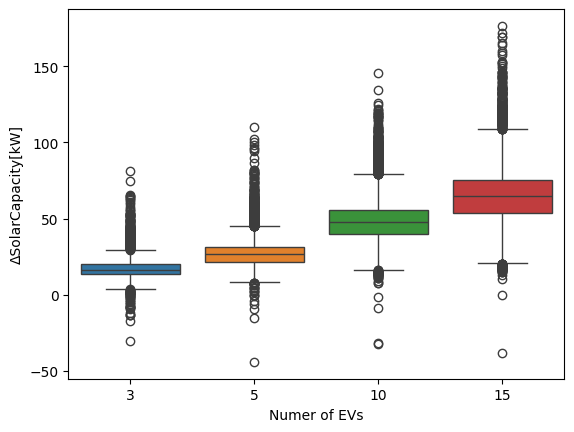

In [21]:
ax = sns.boxplot(delta_solar)
ax.set_xlabel("Numer of EVs")
ax.set_ylabel("ΔSolarCapacity[kW]")
plt.savefig("IMG/delta=solarcapacity")

In [44]:
Cost = pd.DataFrame(Dict["BuyPowerEnergy"])

In [50]:
Cost.describe()

,3,5,10,15
count,5059.000000,5059.000000,5059.000000,5059.000000
mean,21605.986270,32914.569336,62421.153256,90027.863388
std,9292.652193,13299.346519,20550.625607,29258.879605
min,-60850.639886,-74040.153962,-46154.797282,-47467.360691
25%,17162.257547,25945.636314,51169.658386,72659.430962
50%,20116.987391,30911.310784,60306.945945,88820.661262
75%,24269.197007,36355.552985,68543.558929,101113.181084
max,95461.456619,149845.054758,256379.322652,282258.899735


<Axes: xlabel='Numer of EVs', ylabel='ΔCost [10k JPY]'>

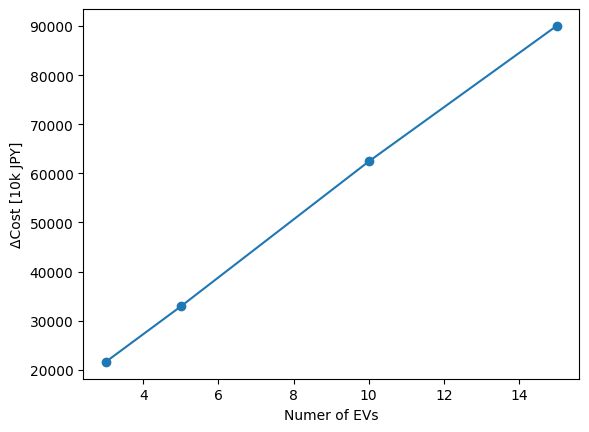

In [47]:
Cost.mean().plot(marker="o",xlabel="Numer of EVs",ylabel="ΔCost [10k JPY]")

In [54]:
for Num_EV in [3,5,10,15]:
    DF = pd.read_csv(f"TEEA_EV{Num_EV}.csv",index_col=0)
    DF_agg = DF.groupby("Scinario").describe()
    print(DF_agg)

c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


           index                                                       \
           count     mean          std  min     25%      50%      75%   
Scinario                                                                
1         5059.0  15174.0  8763.311018  0.0  7587.0  15174.0  22761.0   
2         5059.0  15175.0  8763.311018  1.0  7588.0  15175.0  22762.0   
3         5059.0  15176.0  8763.311018  2.0  7589.0  15176.0  22763.0   
4         5059.0  15177.0  8763.311018  3.0  7590.0  15177.0  22764.0   
5         5059.0  15178.0  8763.311018  4.0  7591.0  15178.0  22765.0   
6         5059.0  15179.0  8763.311018  5.0  7592.0  15179.0  22766.0   

                   Num_EV       ...  Cost_trvl            TotalCost  \
              max   count mean  ...        75%        max     count   
Scinario                        ...                                   
1         30348.0  5059.0  0.0  ...   0.000000   0.000000    5059.0   
2         30349.0  5059.0  0.0  ...  63.086705  63.086705 

c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


           index                                                         \
           count     mean           std  min      25%      50%      75%   
Scinario                                                                  
1         5059.0  20232.0  11684.414691  0.0  10116.0  20232.0  30348.0   
2         5059.0  20233.0  11684.414691  1.0  10117.0  20233.0  30349.0   
3         5059.0  20234.0  11684.414691  2.0  10118.0  20234.0  30350.0   
4         5059.0  20235.0  11684.414691  3.0  10119.0  20235.0  30351.0   
5         5059.0  20236.0  11684.414691  4.0  10120.0  20236.0  30352.0   
6         5059.0  20237.0  11684.414691  5.0  10121.0  20237.0  30353.0   
7         5059.0  20238.0  11684.414691  6.0  10122.0  20238.0  30354.0   
8         5059.0  20239.0  11684.414691  7.0  10123.0  20239.0  30355.0   

                   Num_EV       ...  Cost_trvl            TotalCost  \
              max   count mean  ...        75%        max     count   
Scinario                        

c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


           index                                                         \
           count     mean           std  min      25%      50%      75%   
Scinario                                                                  
1         5059.0  20232.0  11684.414691  0.0  10116.0  20232.0  30348.0   
2         5059.0  20233.0  11684.414691  1.0  10117.0  20233.0  30349.0   
3         5059.0  20234.0  11684.414691  2.0  10118.0  20234.0  30350.0   
4         5059.0  20235.0  11684.414691  3.0  10119.0  20235.0  30351.0   
5         5059.0  20236.0  11684.414691  4.0  10120.0  20236.0  30352.0   
6         5059.0  20237.0  11684.414691  5.0  10121.0  20237.0  30353.0   
7         5059.0  20238.0  11684.414691  6.0  10122.0  20238.0  30354.0   
8         5059.0  20239.0  11684.414691  7.0  10123.0  20239.0  30355.0   

                   Num_EV        ...  Cost_trvl            TotalCost  \
              max   count  mean  ...        75%        max     count   
Scinario                      

c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\kiuch\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [55]:
DF.columns

Index(['index', 'name', 'Num_EV', 'TripEnergy', 'Demand', 'RES',
       'SolarCapacity', 'BESS_BatteryCapacity', 'BuyPowerEnergy',
       'ContractPower', 'Cost', 'EnergyCost', 'ContractCost',
       'Is_opt_solarcapacity', 'Is_opt_BESS', 'TripType', 'ChargeType',
       'ControlRatio', 'Scinario', 'DemandClass', 'cluster', 'SCR[-]',
       'SSR[-]', 'LCOE', 'PBP', 'GHG_prod_ev', 'GHG_prod_ice', 'GHG_prod_pv',
       'GHG_prod_charger', 'GHG_prod_vgi', 'GHG_prod_BESS', 'GHG_trvl',
       'GHG_Comsumption', 'GHG_Total_Production', 'Cost_trvl', 'TotalCost'],
      dtype='object')